In [59]:
import os
import pandas as pd
import joblib

# Thiết lập đường dẫn tới thư mục artifacts (nơi chứa file pkl và csv)
# Nếu file .ipynb nằm cùng thư mục với file script cũ, BASE_DIR sẽ là thư mục cha.
# Bạn có thể điều chỉnh lại đường dẫn cho đúng với cấu trúc thư mục của mình.
BASE_DIR = os.path.dirname(os.getcwd()) # Lấy thư mục cha của thư mục hiện tại
ARTIFACTS_DIR = os.path.join(BASE_DIR, 'artifacts')

print(f"📂 Thư mục chứa artifacts: {ARTIFACTS_DIR}")

📂 Thư mục chứa artifacts: h:\Project-ADY\Project_ADY201m_GR01_AI2009_H1\artifacts


In [60]:
# 1. Load các tập dữ liệu Train/Test đã chia sẵn
X_train = pd.read_csv(os.path.join(ARTIFACTS_DIR, 'X_train_tree.csv'))
X_test = pd.read_csv(os.path.join(ARTIFACTS_DIR, 'X_test_tree.csv'))
y_train = pd.read_csv(os.path.join(ARTIFACTS_DIR, 'y_train_tree.csv'))
y_test = pd.read_csv(os.path.join(ARTIFACTS_DIR, 'y_test_tree.csv'))

# 2. Load Pipeline tiền xử lý (chỉ chứa bước One-Hot Encoder)
preprocessing_pipeline = joblib.load(os.path.join(ARTIFACTS_DIR, 'tree_preprocessing_pipeline.pkl'))

print("✅ Đã load thành công dữ liệu và pipeline vào Notebook!")
print(f"Kích thước tập X_train gốc: {X_train.shape}")

✅ Đã load thành công dữ liệu và pipeline vào Notebook!
Kích thước tập X_train gốc: (5634, 18)


In [61]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train.values.ravel())

print("✅ Random Forest training completed!")

✅ Random Forest training completed!


In [62]:
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

In [63]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_prob)
}

pd.DataFrame([metrics])

,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,0.775018,0.557809,0.735294,0.634371,0.85194


In [64]:
rf_results = pd.DataFrame({
    "Model": ["Random Forest"],
    "Accuracy": [accuracy_score(y_test, y_pred)],
    "Precision": [precision_score(y_test, y_pred)],
    "Recall": [recall_score(y_test, y_pred)],
    "F1-score": [f1_score(y_test, y_pred)],
    "ROC-AUC": [roc_auc_score(y_test, y_prob)]
})

rf_results

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Random Forest,0.775018,0.557809,0.735294,0.634371,0.85194


In [65]:
# Create Feature Importance DataFrame
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

# Remove pipeline prefixes
importance_df['Feature'] = (
    importance_df['Feature']
    .str.replace('remainder__', '', regex=False)
    .str.replace('encoder__', '', regex=False)
)

# Academic-friendly feature names
academic_mapping = {
    'Contract': 'Contract Type',
    'tenure_group': 'Customer Tenure Group',
    'Dependents': 'Dependents Status',
    'InternetService': 'Internet Service Technology',
    'TechSupport': 'Technical Support Opt-in',
    'MonthlyCharges': 'Monthly Charges Fee',
    'TotalCharges': 'Accumulated Total Charges',
    'monthly_charges_ratio': 'Monthly Charges Ratio',
    'service_diversity': 'Service Diversity Index',
    'is_paperless_electronic': 'Paperless & Auto-Payment Combination'
}

# Apply mapping dictionary
importance_df["Feature"] = (
    importance_df["Feature"]
    .map(academic_mapping)
    .fillna(importance_df["Feature"])
)

# Sort by importance
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

# Convert to percentage
importance_df["Importance (%)"] = (
    importance_df["Importance"] * 100
).round(2)

# Display Top 10
importance_df.head(10)

,Feature,Importance,Importance (%)
7,Contract Type,0.186208,18.62
6,Tenure,0.134938,13.49
9,Monthly Charges Fee,0.110508,11.05
16,Monthly Charges Ratio,0.107561,10.76
10,Accumulated Total Charges,0.105309,10.53
0,Dependents Status,0.080355,8.04
3,Customer Tenure Group,0.063436,6.34
2,Internet Service Technology,0.054440,5.44
1,PaymentMethod,0.032250,3.22
15,Service Diversity Index,0.030502,3.05


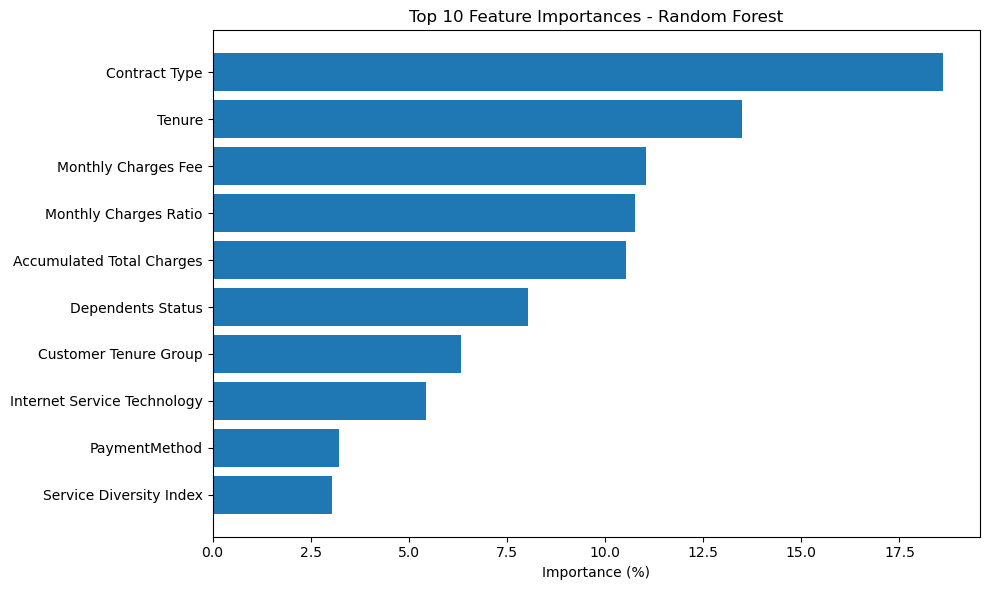

In [69]:
import matplotlib.pyplot as plt

# Chỉ lấy Top 10
top10 = (
    importance_df
    .sort_values("Importance", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

plt.barh(
    top10["Feature"],
    top10["Importance (%)"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance (%)")
plt.ylabel("")
plt.title("Top 10 Feature Importances - Random Forest")

plt.tight_layout()
plt.savefig(
    "rf_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
